The purpose of this notebook is to test the effectiveness of various methods for classifying whether or not a Kepler light curve indicates the presence of an exoplanet. 

In [1]:
import numpy as np 
import pandas as pd
%cd C:\Users\Jared\Desktop\Vol3_project

C:\Users\Jared\Desktop\Vol3_project


In [2]:
train_df = pd.read_csv("ACME_VOL3_PLANET_FINDER\GT\simple_lc\exoTrain.csv")
test_df = pd.read_csv("ACME_VOL3_PLANET_FINDER\GT\simple_lc\exoTest.csv")

In [3]:
train_df = train_df.replace({'LABEL':{1:0, 2:1}})
test_df = test_df.replace({'LABEL':{1:0, 2:1}})

In [4]:
trainx = train_df.drop(['LABEL'], axis=1)
trainy = train_df.LABEL
testx = test_df.drop(['LABEL'], axis=1)
testy = test_df.LABEL

We experiment with different random forests

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=7, n_jobs=-1)
rf.fit(trainx, trainy)
pred = rf.predict(testx)
confusion_matrix(testy, pred)


array([[565,   0],
       [  5,   0]])

In [6]:
rf = RandomForestClassifier(n_estimators=500, max_depth=20, random_state=7, n_jobs=-1)
rf.fit(trainx, trainy)
pred = rf.predict(testx)
confusion_matrix(testy, pred)

array([[565,   0],
       [  5,   0]])

In [7]:
rf = RandomForestClassifier(n_estimators=2, max_depth=20, random_state=7, n_jobs=-1)
rf.fit(trainx, trainy)
pred = rf.predict(testx)
confusion_matrix(testy, pred)

array([[564,   1],
       [  5,   0]])

Now we try and SVM since they can be very effective with high dimensional data

In [ ]:
from sklearn import svm
model = svm.SVC()
model.fit(trainx, trainy)
pred = model.predict(testx)
confusion_matrix(testy, pred) 

array([[565,   0],
       [  5,   0]])

In [10]:
model = svm.SVC(kernel='rbf')
model.fit(trainx, trainy)
pred = model.predict(testx)
confusion_matrix(testy, pred) 

array([[565,   0],
       [  5,   0]])

Let's try scaling the data and see if that improves our results

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
strainx = pd.DataFrame(scaler.fit_transform(trainx), index=trainx.index, columns=trainx.columns)
stestx = pd.DataFrame(scaler.transform(testx), index=testx.index, columns=testx.columns)

In [15]:
from sklearn import svm
model = svm.SVC()
model.fit(strainx, trainy)
pred = model.predict(stestx)
confusion_matrix(testy, pred) 

array([[565,   0],
       [  5,   0]])

In [16]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=7, n_jobs=-1)
rf.fit(strainx, trainy)
pred = rf.predict(stestx)
confusion_matrix(testy, pred)

array([[565,   0],
       [  5,   0]])

Ok, that didn't do much good, but we'll continue to test each method on the scaled and unscaled data

XG boost

In [17]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.fit(trainx, trainy)
pred = model.predict(testx)
confusion_matrix(testy, pred)

array([[565,   0],
       [  5,   0]])

Even scaling the importances doesn't seem to help

In [20]:
model = xgb.XGBClassifier(scale_pos_weight=113)
model.fit(strainx, trainy)
pred = model.predict(stestx)
confusion_matrix(testy, pred)

array([[565,   0],
       [  5,   0]])

In [60]:
model = xgb.XGBClassifier(scale_pos_weight=113, eval_metric='aucpr', colsample_bytree=0.8, max_depth=6, min_child_weight=1, learning_rate=0.05, subsample=0.8)
model.fit(strainx, trainy)
pred = model.predict(stestx)
confusion_matrix(testy, pred)

array([[565,   0],
       [  5,   0]])

PCA

Text(0.5, 1.0, 'PCA with two components')

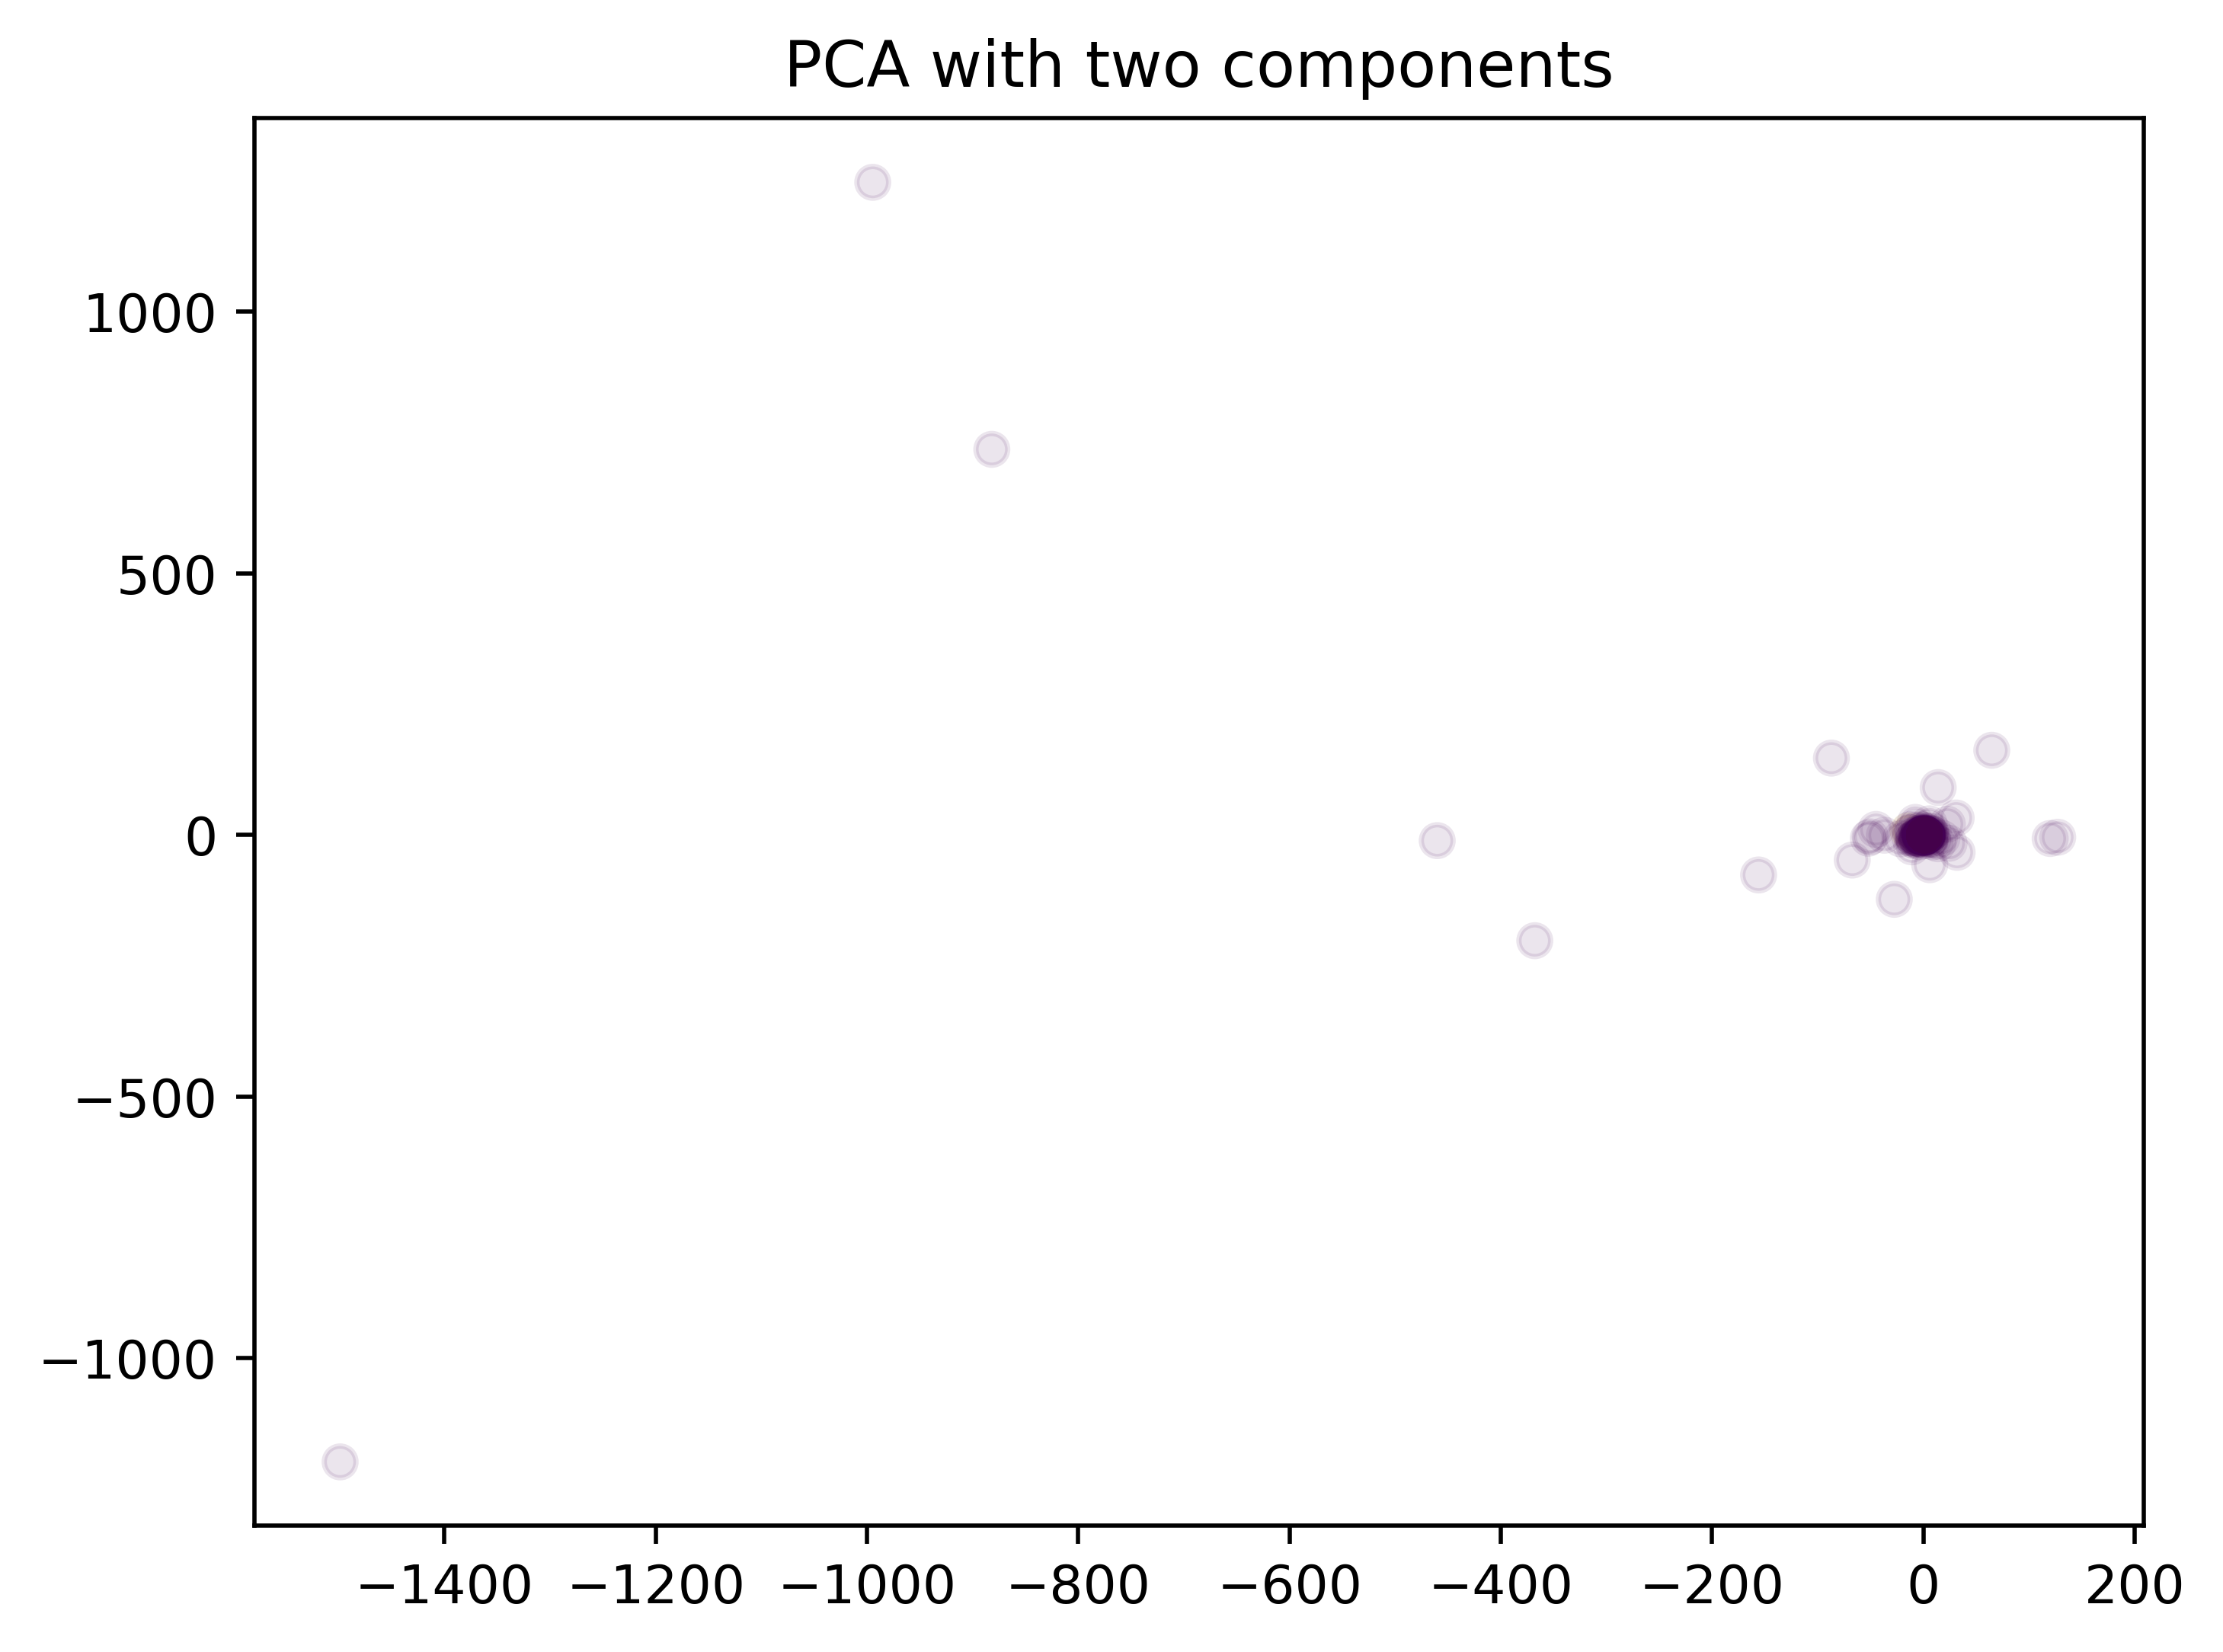

In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 500
pca = PCA(n_components=2)
pc = pca.fit_transform(strainx)
plt.scatter(pc[:, 0], pc[:, 1], c=trainy, alpha=0.1)
plt.title('PCA with two components')

Anomaly detection

In [24]:
from sklearn.ensemble import IsolationForest
antrx = trainx[trainy == 0]
isomodel = IsolationForest(n_estimators=200)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)


array([[550,  15],
       [  4,   1]])

Ok, this is promising, kind of...

In [29]:
isomodel = IsolationForest(n_estimators=500, contamination=0.5)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[283, 282],
       [  1,   4]])

In [30]:
isomodel = IsolationForest(n_estimators=500, contamination=0.25)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[418, 147],
       [  1,   4]])

In [31]:
isomodel = IsolationForest(n_estimators=500, contamination=0.1)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[509,  56],
       [  4,   1]])

In [32]:
isomodel = IsolationForest(n_estimators=500, contamination=0.15)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[477,  88],
       [  3,   2]])

In [33]:
isomodel = IsolationForest(n_estimators=500, contamination=0.2)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[447, 118],
       [  1,   4]])

In [34]:
isomodel = IsolationForest(n_estimators=50, contamination=0.2)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[446, 119],
       [  1,   4]])

In [37]:
isomodel = IsolationForest(n_estimators=50, contamination=0.1)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[510,  55],
       [  4,   1]])

Look's like we're pretty close to optimal contamination, and the number of estimators doesn't play a role, let's test that

In [35]:
isomodel = IsolationForest(n_estimators=5000, contamination=0.2)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[445, 120],
       [  3,   2]])

In [36]:
isomodel = IsolationForest(n_estimators=25, contamination=0.2)
isomodel.fit(antrx)
pred = isomodel.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

array([[449, 116],
       [  3,   2]])

We try a single class svm

In [42]:
from sklearn.svm import OneClassSVM
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)


array([[512,  53],
       [  3,   2]])

In [43]:
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.09)
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)


array([[522,  43],
       [  4,   1]])

In [44]:
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.11)
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)


array([[502,  63],
       [  3,   2]])

We try local outlier factor to see if the data clusters

In [46]:
from sklearn.neighbors import LocalOutlierFactor
model = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto')
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

c:\Users\Jared\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


array([[ 57, 508],
       [  0,   5]])

In [47]:
model = LocalOutlierFactor(n_neighbors=50, novelty=True, contamination='auto')
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

c:\Users\Jared\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


array([[ 71, 494],
       [  0,   5]])

In [48]:
model = LocalOutlierFactor(n_neighbors=500, novelty=True, contamination='auto')
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

c:\Users\Jared\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


array([[163, 402],
       [  0,   5]])

In [49]:
model = LocalOutlierFactor(n_neighbors=5000, novelty=True, contamination='auto')
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

c:\Users\Jared\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


array([[560,   5],
       [  5,   0]])

In [50]:
model = LocalOutlierFactor(n_neighbors=5, novelty=True, contamination='auto')
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]
confusion_matrix(testy, pred)

c:\Users\Jared\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


array([[ 27, 538],
       [  0,   5]])

In [51]:
model = LocalOutlierFactor(n_neighbors=50, novelty=True, contamination=0.02)
model.fit(antrx)
pred = model.predict(testx)
pred = [0 if p == 1 else 1 for p in pred]

print(confusion_matrix(testy, pred))

[[558   7]
 [  5   0]]


c:\Users\Jared\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
